## **_Sample Modeling V5.4_**
- for Reinforcement Learning
- using scikit-fuzzy
- pip install numpy pandas tensor ipykernel torch scikit-learn gymnasium stable_baselines3 scikit-fuzzy

In [1]:
# ----------------------------------------------------
# Global 변수 선언
# ----------------------------------------------------
import os
import sys
from pathlib import Path
from datetime import datetime

version = "v5.4"
csv_file_pathname = lambda: f".{os.sep}data{os.sep}fuzzy_dryer_sensor_{version}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
model_path_name = lambda: f".{os.sep}model{os.sep}fuzzy_dryer_{version}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
global_num_samples = 51200
parent_dir = os.path.dirname(os.getcwd())
project_home_dir = str(Path.cwd().parent.parent)
venv_name = f"samplemodeling{version.replace('.', '_')}"

reward_gen_fn="lib/reward/dryer_oven/gen_reward_v1.py"
reward_gen_fn = reward_gen_fn.replace("/", os.sep)
reward_gen_fn_pythonfile = project_home_dir + os.sep + reward_gen_fn
simulation_cls_pathname = "lib/simulate/dryer_oven_simulation.py"
simulation_cls_pathname = simulation_cls_pathname.replace("/", os.sep)
simulation_cls_pathname = project_home_dir + os.sep + simulation_cls_pathname


In [2]:
# ----------------------------------------------------
# 개발 환경 초기화
# 한 번만 호출하여 주십시요.


# 1.1 set pythonpath to import from parent directory
def _init_environ():
    python_path = os.environ.get("PYTHONPATH")
    if python_path is None:
        python_path = ""
    sys.path.append(parent_dir)
    sys.path.append(project_home_dir)
    python_lib_path = [
        f'{project_home_dir}{os.sep}{venv_name}{os.sep}{"Lib" if sys.platform == "win32" else "lib"}{os.sep}site-packages',
        project_home_dir,
        python_path
    ]
    os.environ["PYTHONPATH"] = ";".join(python_lib_path)

    os.environ["CLEARML_WEB_HOST"] = "http://172.16.8.168:8080/"
    os.environ["CLEARML_API_HOST"] = "http://172.16.8.168:8008/"
    os.environ["CLEARML_FILES_HOST"] = "http://172.16.8.168:8081"
    os.environ["CLEARML_API_ACCESS_KEY"] = "SIJ8V8YP9PL25YEAVAWGP9NV11TMOQ"
    os.environ["CLEARML_API_SECRET_KEY"] = "6x_MEHvgrUv9-TFFDrE9BE7vb3JYOXDWq4kQtqbd58nQ5pqHEGMt6qQXxF7_HCyzq7E"

_init_environ()


In [3]:
!echo $PYTHONPATH
from lib.simulate.dryer_oven_data_genetate import generate_data_v1
from lib.simulate.dryer_oven_data_genetate_v2 import generate_data_v2
from lib.simulate.dryer_oven_data_genetate_v3 import generate_data_v3

# 1. 설정값 초기화
num_samples = global_num_samples
target_temp = 80
initial_temp = 25
drop_envs = [(0.4, 100, 30), (0.5, 200, 40)]
spike_envs = [(0.6, 300, 50), (0.7, 200, 40), (0.8, 200, 70)]

verbose = 0

gen_functions = {"v1": generate_data_v1, "v2": generate_data_v2, "v3": generate_data_v3}
cur_version = "v3"

stored_data_file_pathname = gen_functions[cur_version](drop_envs=drop_envs,
                                                       spike_envs=spike_envs,
                                                       csv_file_pathname=csv_file_pathname(),
                                                       num_samples=global_num_samples,
                                                       target_temp=target_temp,
                                                       initial_temp=initial_temp,
                                                       verbose=verbose)
print(f"Data stored in: {stored_data_file_pathname}")

/home/simpson/work/mlops_jupyter_notebooks/samplemodelingv5_4/lib/site-packages;/home/simpson/work/mlops_jupyter_notebooks;
curr_int_temp = 25
건조기 센서 가상 데이터 생성 완료!
데이터 샘플 (목표 온도: 80도):
Data stored in: ./data/fuzzy_dryer_sensor_v5.4_20260401_223415.csv


#### Step 2 BC 학습

In [4]:
temp_error = lambda x,b: x - b
humidity = lambda x: x / 100.0
weight = lambda x: x
out_temp = lambda x: x
pressure = lambda x: x - 1013.0
fan_rpm = lambda x: x

# temp_error = lambda x,b: x - b
# humidity = lambda x: x / 100.0
# weight = lambda x: x / 100.0
# out_temp = lambda x: x / 40.0
# pressure = lambda x: (x - 1013.0)/50.0
# fan_rpm = lambda x: (x / 3500.0)

In [5]:
import pandas as pd
import torch
import numpy as np

# 1. 전문가 데이터 로드 및 전처리
def load_expert_data(csv_file_pathname, target_temp):
    df = pd.read_csv(csv_file_pathname)
    # 입력: 오차(temp-80), 출력: 전문가의 액션(RPM_Adjust)
    # 6개 변수 추출
    X_data = np.zeros((len(df), 6))
    X_data[:, 0] = temp_error(df['inner_temp'], target_temp)
    X_data[:, 1] = humidity(df['humidity'])
    X_data[:, 2] = weight(df['weight'])
    X_data[:, 3] = out_temp(df['outer_temp'])
    X_data[:, 4] = pressure(df['pressure'])
    X_data[:, 5] = fan_rpm(df['fan_rpm'])
    
    y_data = df['user_action'].values
    return X_data, y_data

In [8]:
# 2. 다변수 Adaptive Neuro-Fuzzy 레이어 정의

import torch
import torch.nn as nn
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import pandas as pd


class FuzzyExpertSystem:
    def __init__(self):
        # 1. 입력 변수 설정 (6개)
        self.error = ctrl.Antecedent(np.arange(-20, 21, 1), 'error')
        self.moisture = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'moisture')
        self.weight = ctrl.Antecedent(np.arange(0, 6, 1), 'weight')
        self.outer_temp = ctrl.Antecedent(np.arange(0, 41, 1), 'outer_temp')
        self.pressure = ctrl.Antecedent(np.arange(-5, 6, 1), 'pressure')
        self.fan_rpm = ctrl.Antecedent(np.arange(800, 3501, 100), 'fan_rpm')

        # 출력 변수 (0: DOWN, 1: KEEP, 2: UP) - 연속 수치로 계산 후 반올림
        self.action = ctrl.Consequent(np.arange(0, 3, 1), 'action')

        # 2. 멤버십 함수 정의 (단순화)
        for var in [self.error, self.moisture, self.weight, self.outer_temp, self.pressure, self.fan_rpm]:
            var.automf(3, names=['low', 'mid', 'high'])

        self.action['down'] = fuzz.trimf(self.action.universe, [0, 0, 1])
        self.action['keep'] = fuzz.trimf(self.action.universe, [0, 1, 2])
        self.action['up'] = fuzz.trimf(self.action.universe, [1, 2, 2])

        # 3. 규칙 생성 (전문가 지식 기반 초기화)
        self.rules = [
            ctrl.Rule(self.error['low'], self.action['down']),
            ctrl.Rule(self.error['high'], self.action['up']),
            ctrl.Rule(self.error['mid'], self.action['keep']),
            # 나머지 변수들을 규칙에 강제로 포함 (예시 규칙들)
            ctrl.Rule(self.moisture['high'], self.action['down']),
            ctrl.Rule(self.weight['high'], self.action['down']),
            ctrl.Rule(self.outer_temp['low'], self.action['keep']),
            ctrl.Rule(self.pressure['high'], self.action['up']),
            ctrl.Rule(self.fan_rpm['high'], self.action['keep'])
        ]
        
        self.control_sys = ctrl.ControlSystem(self.rules)
        self.sim = ctrl.ControlSystemSimulation(self.control_sys)
        

    def get_action(self, obs):
        """
        obs: [error, moisture, weight, outer_temp, pressure, fan_rpm]
        """
        self.sim.input['error'] = np.clip(obs[0], -20, 20)
        self.sim.input['moisture'] = np.clip(obs[1], 0, 1)
        self.sim.input['weight'] = np.clip(obs[2], 0, 5)
        self.sim.input['outer_temp'] = np.clip(obs[3], 0, 40)
        self.sim.input['pressure'] = np.clip(obs[4], -5, 5)
        self.sim.input['fan_rpm'] = np.clip(obs[5], 800, 3500)
        
        try:
            self.sim.compute()
            raw_out = self.sim.output['action']
            # 0, 1, 2로 반올림하여 반환
            return int(np.round(raw_out))
        except:
            return 1 # 연산 실패 시 기본값 KEEP

    def update_logic(self, x_train, y_train):
        """
        전문가 데이터(y_train)와 비교하여 오차(Loss)를 확인하는 로직
        scikit-fuzzy는 자동 학습 기능이 없으므로 성능 지표를 계산합니다.
        """
        correct = 0
        for i in range(len(x_train)):
            pred = self.get_action(x_train[i])
            if pred == y_train[i]:
                correct += 1
        
        accuracy = correct / len(x_train)
        print(f"전문가 데이터 일치율(Accuracy): {accuracy:.4f}")
        return accuracy

# 이 레이어를 포함한 모델을 구성하고 
# 전문가의 Action과 비교하여 Loss를 줄이는 방식으로 학습(BC)을 진행합니다.


In [ ]:
from scipy.optimize import minimize
import torch
import torch.nn as nn
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import pandas as pd


class FuzzyBCRetrainer:
    def __init__(self, csv_path):
        # 1. 전문가 데이터 로드 (BC용)
        self.df = pd.read_csv(csv_path)
        self.target_temp = 80.0
        self.prepare_data()
        
        # 2. 초기 튜닝 파라미터 (Error의 Low, Mid, High 중심점)
        # 이 값들이 전문가 데이터를 통해 '재학습(최적화)'될 대상입니다.
        self.init_params = np.array([-10.0, 0.0, 10.0]) 

    def prepare_data(self):
        # 전문가의 입력(Error)과 정답 액션(0, 1, 2) 추출
        self.X_error = (self.df['inner_temp'] - self.target_temp).values
        self.Y_action = self.df['user_action'].values

    def create_fuzzy_model(self, p):
        """파라미터 p를 받아 실시간으로 퍼지 모델을 생성"""
        error = ctrl.Antecedent(np.arange(-20, 21, 1), 'error')
        moisture = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'moisture')
        weight = ctrl.Antecedent(np.arange(0, 6, 1), 'weight')
        outer_temp = ctrl.Antecedent(np.arange(0, 41, 1), 'outer_temp')
        pressure = ctrl.Antecedent(np.arange(-5, 6, 1), 'pressure')
        fan_rpm = ctrl.Antecedent(np.arange(800, 3501, 100), 'fan_rpm')

        # 출력 변수 (0: DOWN, 1: KEEP, 2: UP) - 연속 수치로 계산 후 반올림
        action = ctrl.Consequent(np.arange(0, 3, 1), 'action')

        # 멤버십 함수 정의 (p[0]: Low중심, p[1]: Mid중심, p[2]: High중심)
        error['low'] = fuzz.trimf(error.universe, [-20, p[0], p[1]])
        error['mid'] = fuzz.trimf(error.universe, [p[0], p[1], p[2]])
        error['high'] = fuzz.trimf(error.universe, [p[1], p[2], 20])

        # 액션 단순화
        action['down'] = fuzz.trimf(action.universe, [0, 0, 1])
        action['keep'] = fuzz.trimf(action.universe, [0, 1, 2])
        action['up'] = fuzz.trimf(action.universe, [1, 2, 2])

        # 2. 멤버십 함수 정의 (단순화)
        for var in [error, moisture, weight, outer_temp, pressure, fan_rpm]:
            var.automf(3, names=['low', 'mid', 'high'])


        # 3. 규칙 생성 (전문가 지식 기반 초기화)
        rules = [
            ctrl.Rule(error['low'], action['down']),
            ctrl.Rule(error['high'], action['up']),
            ctrl.Rule(error['mid'], action['keep']),
            ctrl.Rule(moisture['high'], action['down']),
            ctrl.Rule(weight['high'], action['down']),
            ctrl.Rule(outer_temp['low'], action['keep']),
            ctrl.Rule(pressure['high'], action['up']),
            ctrl.Rule(fan_rpm['high'], action['keep'])
        ]
        
        sys = ctrl.ControlSystem(rules)
        return ctrl.ControlSystemSimulation(sys)

    def loss_function(self, p):
        """전문가 데이터와 퍼지 모델 출력 간의 오차(MSE) 계산"""
        # 파라미터 제약 조건 (순서 유지: Low < Mid < High)
        if not (p[0] < p[1] < p[2]): return 1e6
        
        sim = self.create_fuzzy_sim_fast(p)
        total_loss = 0
        samples = self.X_error[:200] # 속도를 위해 샘플링
        targets = self.Y_action[:200]

        for err, target in zip(samples, targets):
            try:
                sim.input['error'] = np.clip(err, -20, 20)
                sim.compute()
                pred = sim.output['action']
                total_loss += (target - pred) ** 2
            except:
                total_loss += 4.0 # 연산 실패 패널티
        
        return total_loss / len(samples)

    def create_fuzzy_sim_fast(self, p):
        return self.create_fuzzy_model(p)

    def retrain(self):
        print("BC 기반 퍼지 파라미터 재학습 시작...")
        # Nelder-Mead 알고리즘으로 전문가 데이터에 가장 부합하는 중심점 탐색
        res = minimize(self.loss_function, self.init_params, method='Nelder-Mead')
        self.final_params = res.x
        print(f"재학습 완료! 최적화된 중심점: {self.final_params}")
        return self.final_params

# 실행 및 테스트
if __name__ == "__main__":
    trainer = FuzzyBCRetrainer(csv_path=stored_data_file_pathname)
    best_p = trainer.retrain()
    
    # 결과 검증
    final_model = trainer.create_fuzzy_model(best_p)
    final_model.input['error'] = -5.0 # 예: 75도인 상황
    final_model.input['moisture'] = -5.0 # 예: 75도인 상황
    final_model.input['weight'] = 39.0 # 예: 39kg인 상황
    final_model.input['outer_temp'] = 22.0 # 예: 22도인 상황
    final_model.input['pressure'] = 0.0 # 예: 대기압인 상황
    final_model.input['fan_rpm'] = 2000 # 예: 2000 RPM인 상황
    print(f'final_model = {final_model.input}')
    final_model.compute()
    print(f"오차 -5도일 때 최적화된 액션(0~2): {final_model.output['action']:.2f}")

BC 기반 퍼지 파라미터 재학습 시작...
재학습 완료! 최적화된 중심점: [-10.   0.  10.]
final_model = <skfuzzy.control.controlsystem.ControlSystemSimulation object at 0x727e63c8d5b0>
final_model = error : None
moisture : None
weight : None
outer_temp : None
pressure : None
fan_rpm : None

final_model = error : -5.0
moisture : 0.0
weight : 5.0
outer_temp : 22.0
pressure : 0.0
fan_rpm : 2000

오차 -5도일 때 최적화된 액션(0~2): 0.79


#### Step 3 학습 모델로 제어 시뮬레이션

퍼지 파라미터 최적화 시작...
BC 기반 퍼지 파라미터 재학습 시작...
재학습 완료! 최적화된 중심점: [-10.   0.  10.]
hit_point = 16


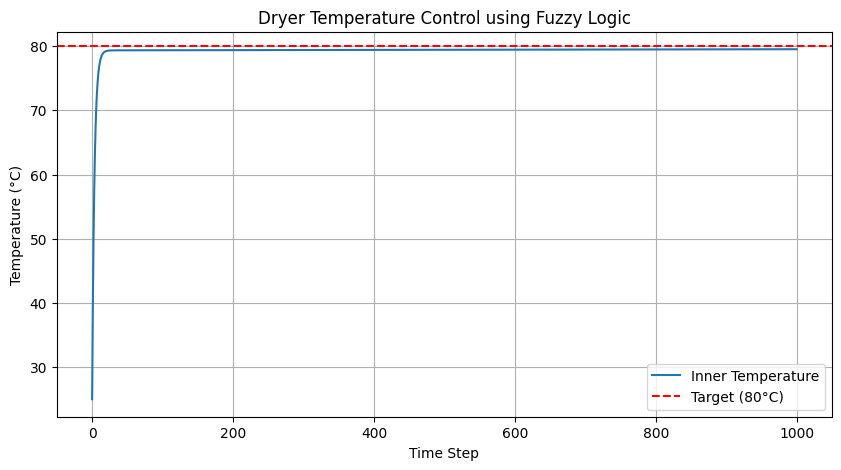

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lib.simulate.dryer_oven_simulation import DryerOvenSimulation
from lib.types import unpack_nptype



# 3. BC(Behavior Cloning) 학습
def train(csv_file_pathname, verbose=0):
    if verbose > 0:
        print("퍼지 파라미터 최적화 시작...")
    
    max_repeat_cnt = 1000
    initial_temp = 25.0
    const_heater_input = 15.5


    simulation = DryerOvenSimulation(use_ts=False,
                                     target_temp=80.0,
                                     initial_temp=initial_temp,
                                     initial_weight=80,
                                     dry_weight=20,
                                     debug=False)
    trainer = FuzzyBCRetrainer(csv_path=stored_data_file_pathname)
    best_p = trainer.retrain()
    final_model = trainer.create_fuzzy_model(best_p)
    init_state = [
            25.0,   # inner_temp 0
            -55.0,  # error      1
            80.0,   # humidity   2
            39.0,   # weight     3
            22.0,   # outer_temp 4
            1013.0, # pressure   5
            1500.0] # fan_rpm    6
    history = []
    state = init_state
    convergence_cnt = 0
    convergenced_cnt = 0
    convergenced_stats = False

    for i in range(max_repeat_cnt):
        history.append(unpack_nptype(state[0])) # inner_temp 기록
        final_model.input['error'] = unpack_nptype(state[1])
        final_model.input['moisture'] = unpack_nptype(state[2])
        final_model.input['weight'] = unpack_nptype(state[3])
        final_model.input['outer_temp'] = unpack_nptype(state[4])
        final_model.input['pressure'] = unpack_nptype(state[5])
        final_model.input['fan_rpm'] = unpack_nptype(state[6])
        final_model.compute()
        action = final_model.output['action']
        state = simulation.step(action=action, state=state, heater_input=const_heater_input)
        state = list(state.values())
        inner_temp = state[0]

        # 수렴 위치 측정
        if abs(inner_temp - target_temp) < 1.5:
            convergenced_stats = True
            convergence_cnt += 1
            if convergence_cnt > 3 and convergenced_stats == True and hit_point == 0:
                convergenced_cnt += 1
                hit_point = i
        else:
            convergenced_stats = False
            convergence_cnt = 0
            hit_point = 0
    return hit_point, history


hit_point, history = train(csv_file_pathname=stored_data_file_pathname, verbose=1)

print(f'hit_point = {hit_point}')

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(history, label='Inner Temperature')
plt.axhline(y=80, color='r', linestyle='--', label='Target (80°C)')
plt.title('Dryer Temperature Control using Fuzzy Logic')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()
